In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

ROOT = Path("/Users/alexgonzalez/Documents/nba_quant")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.points import (
    TIER1_POINTS_FEATURES,
    add_points_features,
)
from src.models.xgboost_models import (
    DEFAULT_POINTS_FEATURES,
    XGBoostConfig,
    XGBoostPointsModel,
    add_predicted_minutes_oof,
)
from src.models.xgboost_models.tuning import tune_prop


In [2]:
s20 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2019-20/regular_season/player_gamelogs.parquet')
s21 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2020-21/regular_season/player_gamelogs.parquet')
s22 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2021-22/regular_season/player_gamelogs.parquet')
s23 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2022-23/regular_season/player_gamelogs.parquet')
s24 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2023-24/regular_season/player_gamelogs.parquet')
s25 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2024-25/regular_season/player_gamelogs.parquet')
s26 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2025-26/regular_season/player_gamelogs.parquet')
df = pd.concat([s20, s21, s22, s23, s24, s25, s26])
print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
df.sample(5)


Number of rows: 176738
Number of columns: 189


,season_year,player_id,player_name,nickname,team_id,team_abbreviation,team_name,game_id,game_date,matchup,...,opp_e_pace,opp_pace,opp_pace_per40,opp_poss,opp_pie,season_type,pos,game_total,team_spread,player_team_spread
13427,2019-20,1626145,Tyus Jones,Tyus,1610612763,MEM,Memphis Grizzlies,0021900420,2019-12-20T00:00:00,MEM @ CLE,...,102.1,100.0,83.33,99,0.516,Regular Season,PG,222.5,2.5,-2.5
19374,2024-25,1628964,Mo Bamba,Mo,1610612746,LAC,LA Clippers,0022400324,2024-12-04T00:00:00,LAC vs. MIN,...,101.3,100.5,83.75,101,0.719,Regular Season,C,212.5,4.0,4.0
11123,2025-26,1641794,Dillon Jones,Dillon,1610612752,NYK,New York Knicks,0022500690,2026-01-30T00:00:00,NYK vs. POR,...,102.3,100.0,83.33,100,0.384,Regular Season,SF,224.0,-6.5,-6.5
4457,2020-21,1630177,Theo Maledon,Theo,1610612760,OKC,Oklahoma City Thunder,0022000882,2021-04-21T00:00:00,OKC @ IND,...,108.9,106.0,88.33,105,0.546,Regular Season,PG,231.0,-9.0,9.0
26202,2023-24,1631096,Chet Holmgren,Chet,1610612760,OKC,Oklahoma City Thunder,0022300070,2023-10-25T00:00:00,OKC @ CHI,...,101.4,99.5,82.92,99,0.411,Regular Season,C,224.0,-2.5,2.5


In [3]:
# adding the features to the whole dataset instead of each season individually to avoid early season features
df = add_points_features(df)

TIER1_POINTS_FEATURES = [
 'predicted_minutes_oof',
 'min_lag_1',
 'min_mean_3',
 'min_ewm_hl_3',
 'min_std_10',
 'start_rate_10',
 'current_team_min_mean',
 'pts_lag_1',
 'pts_mean_3',
 'pts_mean_20',
 'pts_ewm_hl_3',
 'active_pts_mean_10',
 'season_pts_mean',
 'pts_per_min_10',
 'pts_per_min_20',
 'current_team_pts_per_min',
 'fga_per_min_10',
 'fta_per_min_10',
 'usg_wmean_10',
 'ts_agg_20',
 'three_attempt_rate_10',
 'free_throw_rate_10',
 'player_fga_share_10',
 'team_pace_mean_10',
 'team_off_rating_mean_10',
 'opp_pace_mean_10',
 'opp_def_rating_mean_10',
 'expected_possessions',
 'team_spread_canonical',
 'abs_spread',
 'implied_team_total',
 'team_days_since_prev_game',
 'is_back_to_back',
 'player_days_since_appearance',
 'is_home',
 'season_type_cat',
 'pts_mean_3_minus_10',
 'ppm_10_minus_season',
 'expected_points_rate',
 'expected_attempt_volume',
 'usage_x_expected_possessions']

print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"Number of features: {len(TIER1_POINTS_FEATURES)}")
missing = [col for col in TIER1_POINTS_FEATURES if col not in df.columns]
print(f"Missing Tier-1 features: {missing or 'none'}")
df[TIER1_POINTS_FEATURES].head()


Number of rows: 176738
Number of columns: 263
Number of features: 41
Missing Tier-1 features: none


,predicted_minutes_oof,min_lag_1,min_mean_3,min_ewm_hl_3,min_std_10,start_rate_10,current_team_min_mean,pts_lag_1,pts_mean_3,pts_mean_20,...,team_days_since_prev_game,is_back_to_back,player_days_since_appearance,is_home,season_type_cat,pts_mean_3_minus_10,ppm_10_minus_season,expected_points_rate,expected_attempt_volume,usage_x_expected_possessions
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,NaN,10.233333,10.233333,10.233333,NaN,0.0,10.233333,0.0,0.000000,0.00,...,2.0,0.0,2.0,1.0,0.0,0.000000,0.0,NaN,NaN,14.085500
2,NaN,11.900000,11.066667,10.577166,1.178511,0.0,11.066667,2.0,1.000000,1.00,...,2.0,0.0,2.0,1.0,0.0,0.000000,0.0,NaN,NaN,13.130436
3,NaN,10.716667,10.950000,10.605945,0.857483,0.0,10.950000,4.0,2.000000,2.00,...,1.0,1.0,1.0,0.0,0.0,0.000000,0.0,NaN,NaN,16.251990
4,NaN,18.216667,13.611111,12.176033,3.700175,0.0,12.766667,7.0,4.333333,3.25,...,2.0,0.0,2.0,1.0,0.0,1.083333,0.0,NaN,NaN,18.126200


In [4]:
appearances = df.loc[df["minutes"].gt(0)].copy()
appearances["game_date"] = pd.to_datetime(appearances["game_date"])

# Chronological OOF minutes. Actual Game N minutes are never a feature.
appearances = add_predicted_minutes_oof(appearances, league="nba")

holdout_season = "2025-26"
train = appearances.loc[appearances["season_year"] != holdout_season]
test = appearances.loc[appearances["season_year"] == holdout_season]

print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print(
    "Train dates: "
    f"{train['game_date'].min().date()} → {train['game_date'].max().date()}"
)
print(
    "Test dates: "
    f"{test['game_date'].min().date()} → {test['game_date'].max().date()}"
)
print(
    "OOF minutes coverage: "
    f"{appearances['predicted_minutes_oof'].notna().mean():.1%}"
)

model = XGBoostPointsModel(league="nba", feature_columns=TIER1_POINTS_FEATURES)
model.fit(train)

print(f"Features: {len(model.feature_columns)}")
print(f"Calibration cutoff: {model.regressor.training_cutoff.date()}")
print(f"Trees: {model.regressor.model.n_estimators}")


Train rows: 150,062
Test rows: 26,648
Train dates: 2019-10-22 → 2025-04-13
Test dates: 2025-10-21 → 2026-04-12
OOF minutes coverage: 94.7%
Features: 41
Calibration cutoff: 2024-03-18
Trees: 592


In [5]:
import json
import joblib

ARTIFACT_DIR = ROOT / "artifacts" / "models" / "points"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

artifact_path = ARTIFACT_DIR / "xgboost_points.joblib"
meta_path = ARTIFACT_DIR / "xgboost_points_meta.json"

payload = {
    "model": model,
    "feature_columns": list(model.feature_columns),
    "league": model.league,
    "holdout_season": holdout_season,
    "training_cutoff": model.regressor.training_cutoff,
    "n_estimators": int(model.regressor.model.n_estimators),
    "residual_scaling": model.regressor.residual_scaling,
    "objective": model.regressor.objective,
    "n_train": int(len(train)),
    "n_test": int(len(test)),
    "n_calibration_residuals": int(
        len(model.regressor.calibration_residuals)
    ),
}
joblib.dump(payload, artifact_path)

meta = {
    "artifact_path": str(artifact_path),
    "league": payload["league"],
    "holdout_season": payload["holdout_season"],
    "training_cutoff": str(payload["training_cutoff"]),
    "n_estimators": payload["n_estimators"],
    "residual_scaling": payload["residual_scaling"],
    "objective": payload["objective"],
    "n_train": payload["n_train"],
    "n_test": payload["n_test"],
    "n_calibration_residuals": payload["n_calibration_residuals"],
    "n_features": len(payload["feature_columns"]),
    "feature_columns": payload["feature_columns"],
}
meta_path.write_text(json.dumps(meta, indent=2))

print(f"Saved model → {artifact_path}")
print(f"Bytes: {artifact_path.stat().st_size:,}")
print(f"Metadata → {meta_path}")
print(f"Features: {meta['n_features']}")
print(f"Calibration residuals: {meta['n_calibration_residuals']:,}")


Saved model → /Users/alexgonzalez/Documents/nba_quant/artifacts/models/points/xgboost_points.joblib
Bytes: 5,514,945
Metadata → /Users/alexgonzalez/Documents/nba_quant/artifacts/models/points/xgboost_points_meta.json
Features: 41
Calibration residuals: 140,780


In [6]:
from sklearn.metrics import r2_score

def regression_metrics(frame: pd.DataFrame, split: str) -> dict:
    actual = frame["pts"].to_numpy(dtype=float)
    predicted = model.predict_mean(frame)
    return {
        "split": split,
        "n": len(frame),
        "r2": r2_score(actual, predicted),
        "mae": mean_absolute_error(actual, predicted),
        "rmse": float(np.sqrt(mean_squared_error(actual, predicted))),
    }

metrics = pd.DataFrame(
    [
        regression_metrics(train, "train"),
        regression_metrics(test, "test"),
    ]
)
metrics.round(3)


,split,n,r2,mae,rmse
0,train,150062,0.564,4.448,5.797
1,test,26648,0.536,4.503,5.894


In [7]:
from IPython.display import display

cutoff = model.regressor.training_cutoff

chronological = pd.DataFrame(
    [
        regression_metrics(
            train.loc[train["game_date"] < cutoff],
            "development",
        ),
        regression_metrics(
            train.loc[train["game_date"] >= cutoff],
            "calibration",
        ),
        regression_metrics(test, "holdout"),
    ]
)
chronological["notes"] = [
    f"in-sample; dates before {cutoff.date()}",
    "in-sample after refit; used for early stopping",
    "2025-26 out-of-sample",
]

by_season = pd.DataFrame(
    [
        {
            **regression_metrics(
                appearances.loc[appearances["season_year"].eq(season)],
                season,
            ),
            "role": "holdout" if season == holdout_season else "train",
        }
        for season in sorted(appearances["season_year"].unique())
    ]
)

print("Chronological splits")
display(chronological.round(3))
print("By season")
display(by_season.round(3))


Chronological splits


,split,n,r2,mae,rmse,notes
0,development,119055,0.565,4.446,5.790,in-sample; dates before 2024-03-18
1,calibration,31007,0.562,4.456,5.825,in-sample after refit; used for early stopping
2,holdout,26648,0.536,4.503,5.894,2025-26 out-of-sample


By season


,split,n,r2,mae,rmse,role
0,2019-20,22387,0.536,4.515,5.847,train
1,2020-21,23053,0.564,4.386,5.712,train
2,2021-22,26035,0.544,4.440,5.776,train
3,2022-23,25892,0.579,4.490,5.871,train
4,2023-24,26393,0.591,4.398,5.747,train
5,2024-25,26302,0.561,4.461,5.826,train
6,2025-26,26648,0.536,4.503,5.894,holdout


Best features by gain


,rank,feature,gain,gain_share,weight,cover
0,1,pts_ewm_hl_3,177700.0938,0.5097,238.0,45954.9531
1,2,pts_mean_20,86464.9062,0.2480,245.0,32521.0410
2,3,season_pts_mean,32204.4004,0.0924,408.0,34911.0391
3,4,player_fga_share_10,9023.7383,0.0259,207.0,29961.6328
4,5,expected_attempt_volume,8456.3848,0.0243,322.0,27047.1934
5,6,expected_points_rate,7763.9307,0.0223,189.0,26934.0527
6,7,predicted_minutes_oof,4483.6753,0.0129,386.0,29675.0137
7,8,start_rate_10,1810.3453,0.0052,79.0,47760.3281
8,9,current_team_pts_per_min,1772.6118,0.0051,399.0,42494.7070
9,10,min_lag_1,1511.8129,0.0043,330.0,36261.3789


Worst features by gain


,rank,feature,gain,gain_share,weight,cover
0,41,season_type_cat,0.0000,0.0000,0.0,0.0000
1,40,is_home,374.9935,0.0011,64.0,90450.1250
2,39,is_back_to_back,384.7164,0.0011,2.0,40877.0000
3,38,fga_per_min_10,392.4267,0.0011,123.0,21359.0234
4,37,pts_per_min_10,433.6171,0.0012,159.0,49201.8984
5,36,expected_possessions,436.2404,0.0013,204.0,32148.3477
6,35,abs_spread,437.9655,0.0013,127.0,18804.8984
7,34,team_off_rating_mean_10,443.6094,0.0013,207.0,19949.4883
8,33,min_ewm_hl_3,449.5886,0.0013,123.0,20263.9023
9,32,pts_mean_3_minus_10,450.9956,0.0013,254.0,25853.0703


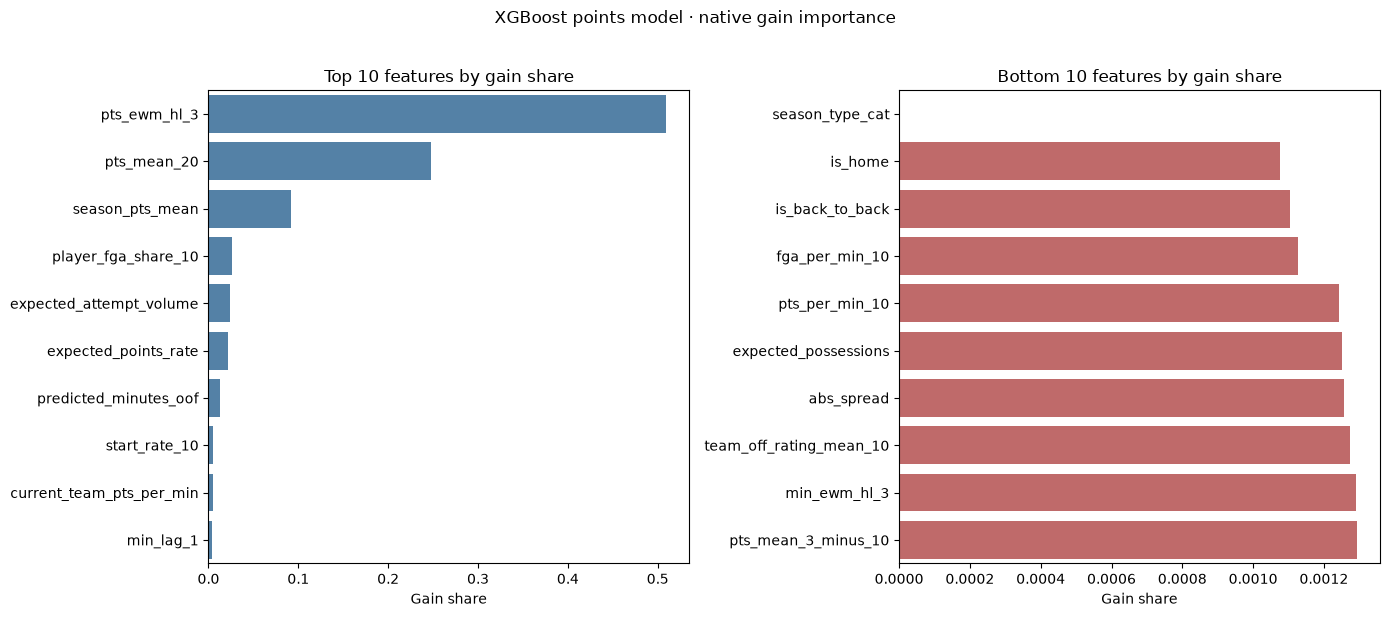

In [8]:
booster = model.regressor.model.get_booster()
importance = pd.DataFrame({"feature": model.feature_columns})
for kind in ("weight", "gain", "cover"):
    scores = booster.get_score(importance_type=kind)
    importance[kind] = importance["feature"].map(scores).fillna(0.0)

importance["gain_share"] = importance["gain"] / importance["gain"].sum()
importance = importance.sort_values("gain", ascending=False).reset_index(drop=True)
importance["rank"] = np.arange(1, len(importance) + 1)

top_n = 10
best = importance.head(top_n)
worst = importance.tail(top_n).iloc[::-1].reset_index(drop=True)

print("Best features by gain")
display(best[["rank", "feature", "gain", "gain_share", "weight", "cover"]].round(4))
print("Worst features by gain")
display(worst[["rank", "feature", "gain", "gain_share", "weight", "cover"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(
    data=best,
    y="feature",
    x="gain_share",
    ax=axes[0],
    color="steelblue",
    order=best["feature"],
)
axes[0].set_title("Top 10 features by gain share")
axes[0].set_xlabel("Gain share")
axes[0].set_ylabel("")

sns.barplot(
    data=worst,
    y="feature",
    x="gain_share",
    ax=axes[1],
    color="indianred",
    order=worst["feature"],
)
axes[1].set_title("Bottom 10 features by gain share")
axes[1].set_xlabel("Gain share")
axes[1].set_ylabel("")
fig.suptitle("XGBoost points model · native gain importance", y=1.02)
fig.tight_layout()
plt.show()


Holdout baseline MAE: 4.503
Best features by holdout permutation MAE increase


,perm_rank,feature,mae_increase,mae_increase_std,gain_rank,gain_share
0,1,pts_ewm_hl_3,0.5256,0.0138,1,0.5097
1,2,pts_mean_20,0.1839,0.0060,2,0.2480
2,3,season_pts_mean,0.1711,0.0042,3,0.0924
3,4,expected_attempt_volume,0.1624,0.0037,5,0.0243
4,5,predicted_minutes_oof,0.0696,0.0023,7,0.0129
5,6,expected_points_rate,0.0489,0.0024,6,0.0223
6,7,current_team_pts_per_min,0.0408,0.0026,9,0.0051
7,8,min_lag_1,0.0281,0.0021,10,0.0043
8,9,opp_def_rating_mean_10,0.0215,0.0020,16,0.0019
9,10,start_rate_10,0.0100,0.0010,8,0.0052


Worst features by holdout permutation MAE increase


,perm_rank,feature,mae_increase,mae_increase_std,gain_rank,gain_share
0,41,active_pts_mean_10,-0.0049,0.0007,13,0.0025
1,40,min_mean_3,-0.0033,0.0003,20,0.0017
2,39,abs_spread,-0.0000,0.0001,35,0.0013
3,38,season_type_cat,0.0000,0.0000,41,0.0000
4,37,is_back_to_back,0.0000,0.0000,39,0.0011
5,36,team_pace_mean_10,0.0002,0.0001,15,0.0023
6,35,three_attempt_rate_10,0.0006,0.0006,28,0.0015
7,34,fga_per_min_10,0.0008,0.0002,38,0.0011
8,33,usg_wmean_10,0.0010,0.0003,12,0.0026
9,32,pts_per_min_10,0.0010,0.0013,37,0.0012


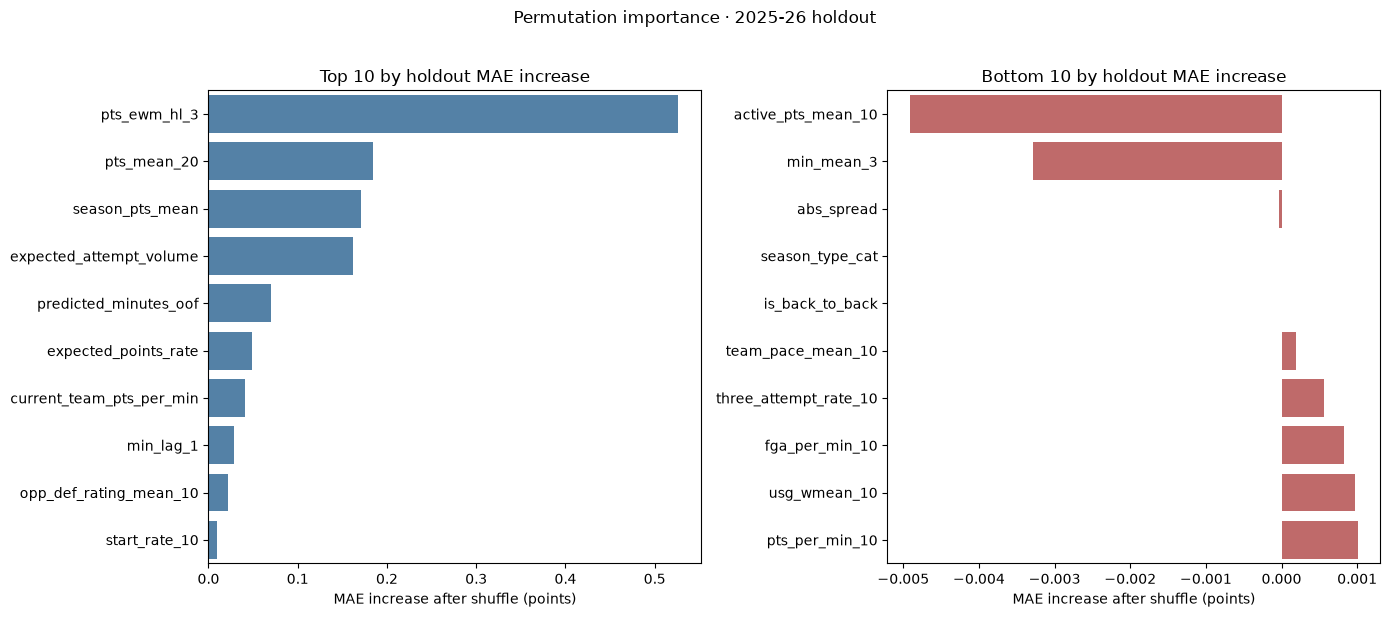

In [9]:
from sklearn.inspection import permutation_importance

X_test = test.loc[:, model.feature_columns].apply(
    pd.to_numeric, errors="coerce"
)
y_test = test["pts"].to_numpy(dtype=float)
baseline_mae = mean_absolute_error(y_test, model.predict_mean(test))

permutation = permutation_importance(
    model.regressor.model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

perm = pd.DataFrame(
    {
        "feature": model.feature_columns,
        "mae_increase": permutation.importances_mean,
        "mae_increase_std": permutation.importances_std,
    }
)
perm = perm.merge(
    importance[["feature", "gain_share", "rank"]].rename(
        columns={"rank": "gain_rank"}
    ),
    on="feature",
    how="left",
)
perm = perm.sort_values("mae_increase", ascending=False).reset_index(
    drop=True
)
perm["perm_rank"] = np.arange(1, len(perm) + 1)

best_perm = perm.head(top_n)
worst_perm = perm.tail(top_n).iloc[::-1].reset_index(drop=True)
columns = [
    "perm_rank",
    "feature",
    "mae_increase",
    "mae_increase_std",
    "gain_rank",
    "gain_share",
]

print(f"Holdout baseline MAE: {baseline_mae:.3f}")
print("Best features by holdout permutation MAE increase")
display(best_perm[columns].round(4))
print("Worst features by holdout permutation MAE increase")
display(worst_perm[columns].round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(
    data=best_perm,
    y="feature",
    x="mae_increase",
    ax=axes[0],
    color="steelblue",
    order=best_perm["feature"],
)
axes[0].set_title("Top 10 by holdout MAE increase")
axes[0].set_xlabel("MAE increase after shuffle (points)")
axes[0].set_ylabel("")

sns.barplot(
    data=worst_perm,
    y="feature",
    x="mae_increase",
    ax=axes[1],
    color="indianred",
    order=worst_perm["feature"],
)
axes[1].set_title("Bottom 10 by holdout MAE increase")
axes[1].set_xlabel("MAE increase after shuffle (points)")
axes[1].set_ylabel("")
fig.suptitle("Permutation importance · 2025-26 holdout", y=1.02)
fig.tight_layout()
plt.show()


In [10]:
dropped = perm.loc[perm["mae_increase"] < 0].sort_values(
    "mae_increase"
)
dropped_features = dropped["feature"].tolist()
reduced_features = [
    column
    for column in TIER1_POINTS_FEATURES
    if column not in set(dropped_features)
]

print(
    f"Dropped {len(dropped_features)} features with negative "
    "holdout permutation MAE"
)
display(
    dropped[
        ["perm_rank", "feature", "mae_increase", "mae_increase_std"]
    ].round(4)
)
print(
    f"Reduced feature set: {len(reduced_features)} / "
    f"{len(TIER1_POINTS_FEATURES)} kept"
)
reduced_features


Dropped 3 features with negative holdout permutation MAE


,perm_rank,feature,mae_increase,mae_increase_std
40,41,active_pts_mean_10,-0.0049,0.0007
39,40,min_mean_3,-0.0033,0.0003
38,39,abs_spread,-0.0000,0.0001


Reduced feature set: 38 / 41 kept


['predicted_minutes_oof',
 'min_lag_1',
 'min_ewm_hl_3',
 'min_std_10',
 'start_rate_10',
 'current_team_min_mean',
 'pts_lag_1',
 'pts_mean_3',
 'pts_mean_20',
 'pts_ewm_hl_3',
 'season_pts_mean',
 'pts_per_min_10',
 'pts_per_min_20',
 'current_team_pts_per_min',
 'fga_per_min_10',
 'fta_per_min_10',
 'usg_wmean_10',
 'ts_agg_20',
 'three_attempt_rate_10',
 'free_throw_rate_10',
 'player_fga_share_10',
 'team_pace_mean_10',
 'team_off_rating_mean_10',
 'opp_pace_mean_10',
 'opp_def_rating_mean_10',
 'expected_possessions',
 'team_spread_canonical',
 'implied_team_total',
 'team_days_since_prev_game',
 'is_back_to_back',
 'player_days_since_appearance',
 'is_home',
 'season_type_cat',
 'pts_mean_3_minus_10',
 'ppm_10_minus_season',
 'expected_points_rate',
 'expected_attempt_volume',
 'usage_x_expected_possessions']

In [11]:
from src.models.evaluation import (
    interval_coverage,
    negative_log_likelihood,
    probability_integral_transform,
)

eval_frame = test.copy()
start_text = (
    eval_frame["start_position"].astype("string").str.strip()
)
eval_frame["actual_starter"] = (
    start_text.notna()
    & start_text.ne("")
    & start_text.ne("nan")
    & start_text.ne("<NA>")
)
eval_frame["has_expected_role"] = eval_frame["start_rate_10"].notna()
eval_frame["expected_starter"] = (
    eval_frame["start_rate_10"] >= 0.5
)
eval_frame["role_shock"] = (
    eval_frame["has_expected_role"]
    & (
        eval_frame["expected_starter"]
        != eval_frame["actual_starter"]
    )
)

actual = eval_frame["pts"].to_numpy(dtype=float)
samples = model.simulate(eval_frame, simulations=2_000)

print(f"Simulated draws: {samples.shape}")
print(
    "Expected starter rows: "
    f"{int(eval_frame.loc[eval_frame['has_expected_role'], 'expected_starter'].sum()):,}"
)
print(f"Actual starter rows: {int(eval_frame['actual_starter'].sum()):,}")
print(f"Role shock rows: {int(eval_frame['role_shock'].sum()):,}")
print(
    "Missing start_rate_10: "
    f"{int((~eval_frame['has_expected_role']).sum()):,}"
)


Simulated draws: (26648, 2000)
Expected starter rows: 11,945
Actual starter rows: 12,300
Role shock rows: 3,426
Missing start_rate_10: 104


In [12]:
def slice_metrics(
    mask: pd.Series,
    split: str,
) -> dict:
    row_mask = mask.to_numpy()
    slice_samples = samples[row_mask]
    slice_actual = actual[row_mask]
    pit = probability_integral_transform(
        slice_samples,
        slice_actual,
    )
    return {
        "split": split,
        "n": int(row_mask.sum()),
        "coverage_80": interval_coverage(
            slice_samples,
            slice_actual,
        ),
        "pit_mean": float(pit.mean()),
        "pit_std": float(pit.std()),
        "nll": negative_log_likelihood(
            slice_samples,
            slice_actual,
        ),
    }

expected_known = eval_frame["has_expected_role"]
distribution_metrics = pd.DataFrame(
    [
        slice_metrics(
            pd.Series(True, index=eval_frame.index),
            "all",
        ),
        slice_metrics(
            expected_known & eval_frame["expected_starter"],
            "expected_starter",
        ),
        slice_metrics(
            expected_known & ~eval_frame["expected_starter"],
            "expected_bench",
        ),
        slice_metrics(
            eval_frame["actual_starter"],
            "actual_starter",
        ),
        slice_metrics(
            ~eval_frame["actual_starter"],
            "actual_bench",
        ),
        slice_metrics(
            eval_frame["role_shock"],
            "role_shock",
        ),
    ]
)
distribution_metrics.round(3)


,split,n,coverage_80,pit_mean,pit_std,nll
0,all,26648,0.800,0.486,0.299,3.014
1,expected_starter,11945,0.727,0.492,0.314,3.317
2,expected_bench,14599,0.859,0.482,0.287,2.770
3,actual_starter,12300,0.722,0.518,0.315,3.358
4,actual_bench,14348,0.867,0.459,0.283,2.719
5,role_shock,3426,0.762,0.526,0.307,3.177


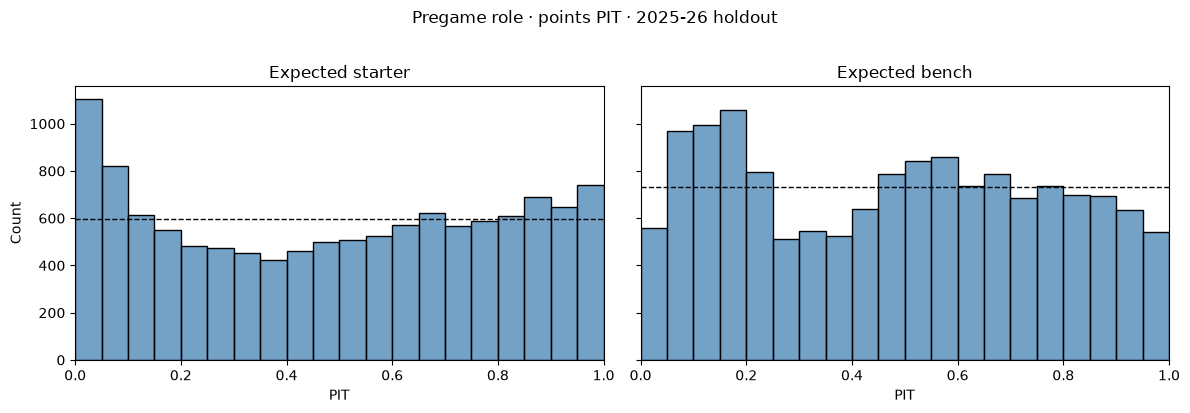

In [13]:
eval_frame["pit"] = probability_integral_transform(
    samples,
    actual,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, title, mask in (
    (
        axes[0],
        "Expected starter",
        eval_frame["has_expected_role"]
        & eval_frame["expected_starter"],
    ),
    (
        axes[1],
        "Expected bench",
        eval_frame["has_expected_role"]
        & ~eval_frame["expected_starter"],
    ),
):
    sns.histplot(
        eval_frame.loc[mask, "pit"],
        bins=20,
        binrange=(0, 1),
        ax=axis,
        color="steelblue",
    )
    axis.axhline(
        len(eval_frame.loc[mask]) / 20,
        color="black",
        linestyle="--",
        linewidth=1,
        label="uniform",
    )
    axis.set_title(title)
    axis.set_xlabel("PIT")
    axis.set_xlim(0, 1)
fig.suptitle(
    "Pregame role · points PIT · 2025-26 holdout",
    y=1.02,
)
fig.tight_layout()
plt.show()


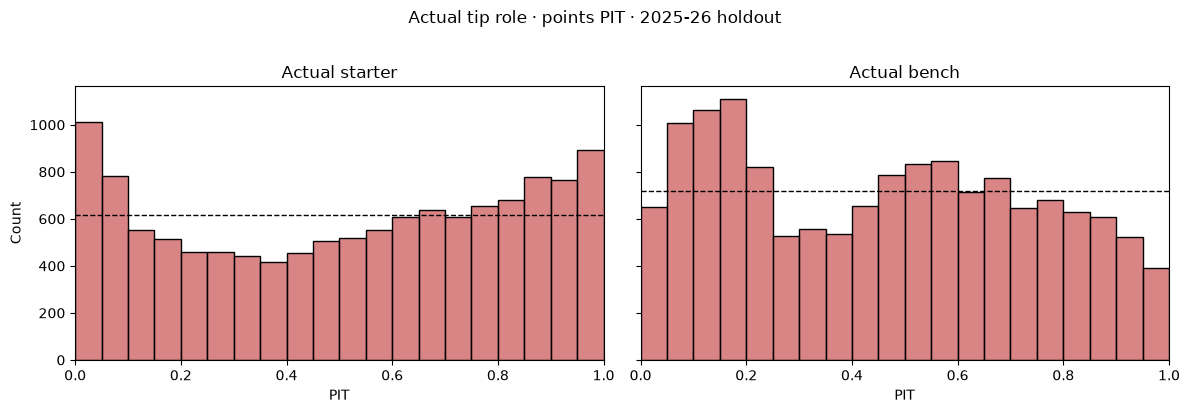

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, title, mask in (
    (axes[0], "Actual starter", eval_frame["actual_starter"]),
    (axes[1], "Actual bench", ~eval_frame["actual_starter"]),
):
    sns.histplot(
        eval_frame.loc[mask, "pit"],
        bins=20,
        binrange=(0, 1),
        ax=axis,
        color="indianred",
    )
    axis.axhline(
        len(eval_frame.loc[mask]) / 20,
        color="black",
        linestyle="--",
        linewidth=1,
        label="uniform",
    )
    axis.set_title(title)
    axis.set_xlabel("PIT")
    axis.set_xlim(0, 1)
fig.suptitle(
    "Actual tip role · points PIT · 2025-26 holdout",
    y=1.02,
)
fig.tight_layout()
plt.show()


In [15]:
sat = (
    eval_frame["has_expected_role"]
    & eval_frame["expected_starter"]
    & ~eval_frame["actual_starter"]
)
started = (
    eval_frame["has_expected_role"]
    & ~eval_frame["expected_starter"]
    & eval_frame["actual_starter"]
)

role_shock_metrics = pd.DataFrame(
    [
        slice_metrics(sat, "expected_starter_sat"),
        slice_metrics(started, "expected_bench_started"),
    ]
)
print(
    "Role shock is expected role ≠ actual tip starter. "
    "Coverage collapse or PIT piled at 0/1 means the "
    "points module does not widen when the rotation moves."
)
role_shock_metrics.round(3)


Role shock is expected role ≠ actual tip starter. Coverage collapse or PIT piled at 0/1 means the points module does not widen when the rotation moves.


,split,n,coverage_80,pit_mean,pit_std,nll
0,expected_starter_sat,1539,0.787,0.425,0.294,3.000
1,expected_bench_started,1887,0.741,0.608,0.292,3.322
